In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/London/enriched/listing_master.csv")

df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_3

In [25]:
# feature selection
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    "occupancy_rate",
    "number_of_reviews",
    "reviews_per_month",
    "review_frequency",
    "host_tenure_years",
    "review_scores_rating",
    "neighbourhood_median_price",
    "neighbourhood_listing_count",
    "neighbourhood_avg_rating",
    "room_type",
    "property_type",
    "host_is_superhost"
]

In [26]:
# Amenity Feature Engineering

amenities = [
    "Wifi",
    "Kitchen",
    "Air conditioning",
    "Washer",
    "Pool"
]

for amenity in amenities:

    column_name = (
        "has_"
        + amenity.lower().replace(" ", "_")
    )

    df[column_name] = (
        df["amenities"]
        .str.contains(
            amenity,
            case=False,
            na=False
        )
        .astype(int)
    )

In [27]:
features.extend([
    "has_wifi",
    "has_kitchen",
    "has_air_conditioning",
    "has_washer",
    "has_pool"
])

In [28]:
features

['accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'minimum_nights',
 'availability_365',
 'occupancy_rate',
 'number_of_reviews',
 'reviews_per_month',
 'review_frequency',
 'host_tenure_years',
 'review_scores_rating',
 'neighbourhood_median_price',
 'neighbourhood_listing_count',
 'neighbourhood_avg_rating',
 'room_type',
 'property_type',
 'host_is_superhost',
 'has_wifi',
 'has_kitchen',
 'has_air_conditioning',
 'has_washer',
 'has_pool']

In [29]:
target = "price_clean"

model_df = df[
    features + [target]
].copy()

In [30]:
# checking for missing Values
model_df.isnull().sum().sort_values(ascending=False).head(20)

price_clean                    34908
review_frequency               24122
reviews_per_month              24122
review_scores_rating           24122
bedrooms                       12775
host_is_superhost               1766
host_tenure_years                 41
accommodates                       0
number_of_reviews                  0
occupancy_rate                     0
availability_365                   0
minimum_nights                     0
bathrooms                          0
beds                               0
neighbourhood_median_price         0
neighbourhood_listing_count        0
room_type                          0
neighbourhood_avg_rating           0
has_wifi                           0
property_type                      0
dtype: int64

In [31]:
model_df = model_df.dropna()

In [32]:
model_df.shape

(46790, 24)

In [33]:
# One Hot Encoding Categorical columns

model_df = pd.get_dummies(
    model_df,
    columns=[
        "room_type",
        "property_type",
        "host_is_superhost"
    ],
    drop_first=True
)

In [34]:
df["price_clean"].describe()

count    6.196300e+04
mean     2.299170e+02
std      4.437589e+03
min      7.000000e+00
25%      7.700000e+01
50%      1.350000e+02
75%      2.210000e+02
max      1.085147e+06
Name: price_clean, dtype: float64

In [35]:
df["price_clean"].quantile([
    0.90,
    0.95,
    0.99
])

0.90     360.0
0.95     500.0
0.99    1100.0
Name: price_clean, dtype: float64

In [36]:
df["price_clean"].sort_values(
    ascending=False
).head(20)

83405    1085147.0
10228      74100.0
77023      66189.0
54442      65000.0
57204      58000.0
75312      58000.0
9489       53588.0
38591      50000.0
51162      50000.0
63728      30812.0
69658      30000.0
69137      28000.0
60054      25106.0
54422      22824.0
67625      20000.0
69489      15143.0
65735      15000.0
77359      12000.0
53628      12000.0
82435      11952.0
Name: price_clean, dtype: float64

In [37]:
upper = df["price_clean"].quantile(0.99)

df = df[
    df["price_clean"] <= upper
].copy()

In [38]:
model_df["log_price"] = np.log1p(
    model_df["price_clean"]
)

In [39]:
X = model_df.drop(
    columns=["price_clean", "log_price"]
)

y = model_df["log_price"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
print(X_train.shape)
print(X_test.shape)

(37432, 98)
(9358, 98)


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [43]:
models = {
    "Linear Regression":LinearRegression(),

    "Random Forest":RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":GradientBoostingRegressor(
            random_state=42
        )
}

In [44]:
from sklearn.model_selection import cross_validate

In [45]:
results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=[
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
            "r2"
        ]
    )

    results.append({
        "Model": name,
        "MAE":
            -scores[
                "test_neg_mean_absolute_error"
            ].mean(),

        "RMSE":
            -scores[
                "test_neg_root_mean_squared_error"
            ].mean(),

        "R2":
            scores[
                "test_r2"
            ].mean()
    })

In [46]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

results_df.round(3)

,Model,MAE,RMSE,R2
1,Random Forest,0.280,0.404,0.707
2,Gradient Boosting,0.282,0.407,0.703
0,Linear Regression,0.304,0.435,0.660


## Residual Analysis

In [47]:
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [48]:
y_pred = best_model.predict(X_test)

In [49]:
# residuals

residuals = y_test - y_pred

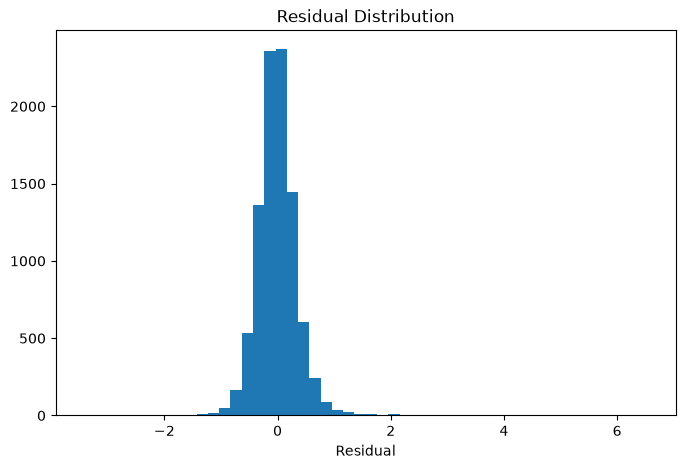

In [51]:
# residual distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50
)

plt.title(
    "Residual Distribution"
)

plt.xlabel("Residual")

plt.show()

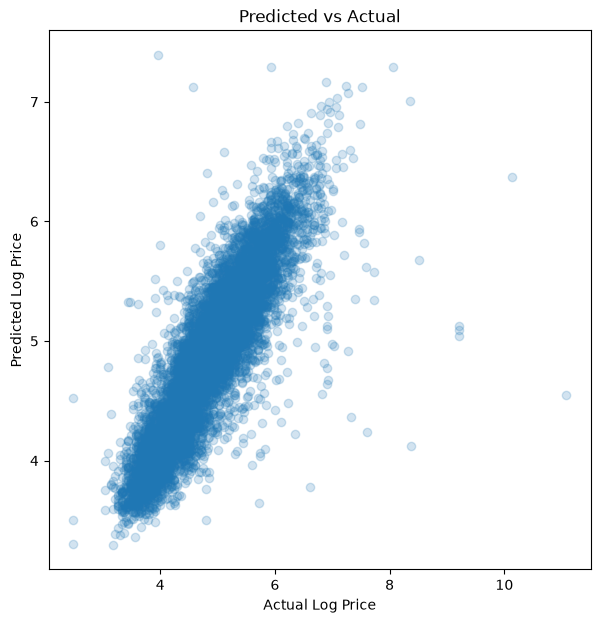

In [52]:
# predicted vs Actual

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.2
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title(
    "Predicted vs Actual"
)

plt.show()

## SHAP

In [56]:
import shap

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [58]:
# sampling data

sample_X = X_test.sample(
    1000,
    random_state=42
)

In [59]:
# explainer

explainer = shap.TreeExplainer(
    best_model
)

In [60]:
# creating shap values

shap_values = explainer.shap_values(
    sample_X
)

In [61]:
# top features

feature_importance = pd.DataFrame({
    "Feature": sample_X.columns,
    "Mean_SHAP": np.abs(
        shap_values
    ).mean(axis=0)
})

feature_importance = (
    feature_importance
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Mean_SHAP
21,room_type_Private room,0.327735
12,neighbourhood_median_price,0.164048
3,bathrooms,0.124362
0,accommodates,0.092794
1,bedrooms,0.092683
8,reviews_per_month,0.053368
11,review_scores_rating,0.050511
17,has_air_conditioning,0.032575
6,occupancy_rate,0.024977
5,availability_365,0.022542


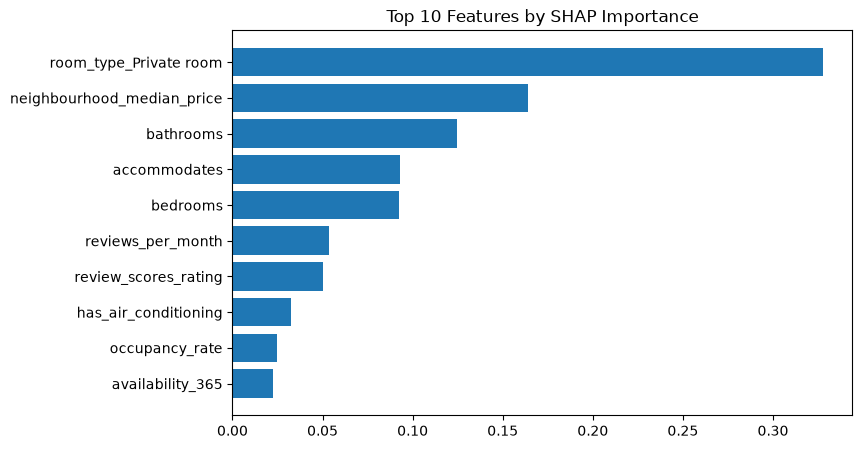

In [62]:
top10 = (
    feature_importance
    .head(10)
)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Mean_SHAP"]
)

plt.title(
    "Top 10 Features by SHAP Importance"
)

plt.gca().invert_yaxis()

plt.show()